In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import math

In [5]:
df = pd.read_csv("Integrated Data Final.csv")
print(df['duration_seconds'].max())
df.head()

57468


,url,title,category,duration_seconds,view_count,like_count,comment_count
0,https://www.youtube.com/watch?v=zuiU_mD-p0c,This ONE Bible Verse Boosted My Faith #Shorts,religious content,55,1097261,165069,45568
1,https://www.youtube.com/watch?v=ztFAl1To3Wo,Ever tried Crispy Banana Bonda 🤤#shorts,food recipes,52,95273478,1468403,6862
2,https://www.youtube.com/watch?v=zpQ_jC57W4E,Camera Flash tip for beginners - Godox v1 lamp...,photography tutorials,23,479077,9712,92
3,https://www.youtube.com/watch?v=zlomFl0KSVQ,Extend Background Photo - Short Photoshop Tuto...,photography tutorials,31,198509,7118,24
4,https://www.youtube.com/watch?v=zeKkx4NsvCg,Og And Saaho Idharu Brothers Ani Telusundhi | ...,cinema content,24,27017,940,2


In [31]:
df['likes_per_view'] = df['like_count'] / df['view_count']
df['comments_per_view'] = df['comment_count'] / df['view_count']
df['duration_seconds'].max()

np.int64(57468)

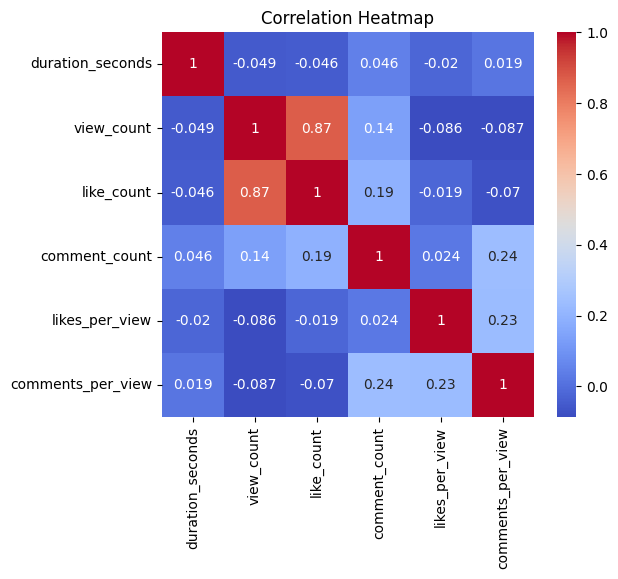

In [32]:
plt.figure(figsize=(6,5))
numeric_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

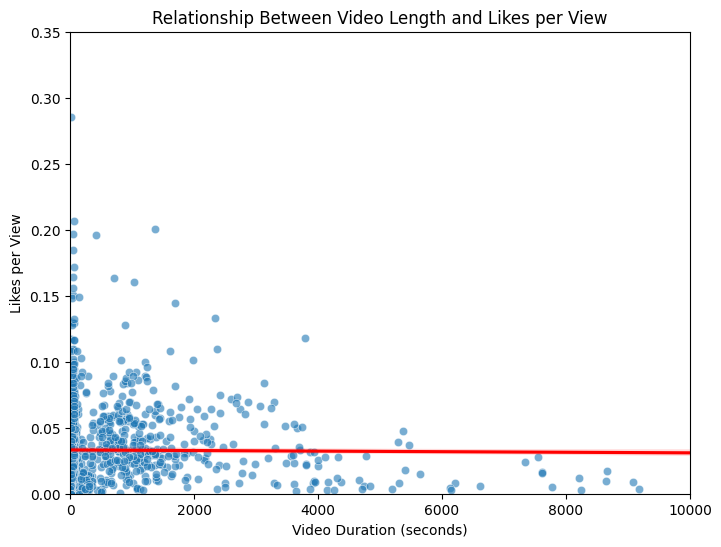

In [18]:
plt.figure(figsize=(8,6))

# Scatter plot
sns.scatterplot(data=df, x='duration_seconds', y='likes_per_view', alpha=0.6)

# Trend line
sns.regplot(data=df, x='duration_seconds', y='likes_per_view', scatter=False, color='red')

# Axis labels and title
plt.xlabel("Video Duration (seconds)")
plt.ylabel("Likes per View")
plt.title("Relationship Between Video Length and Likes per View")

# Limit y-axis to 0 - 0.5
plt.ylim(0, 0.35)
plt.xlim(0, 10000)

plt.show()

In [8]:
print(df['view_count'].mean())
print(df['duration_seconds'].mean())
print(df['likes_per_view'].mean())
print(df['comments_per_view'].mean())

14157334.56115942
988.3791304347826
0.03294405617976388
0.001254777220258607


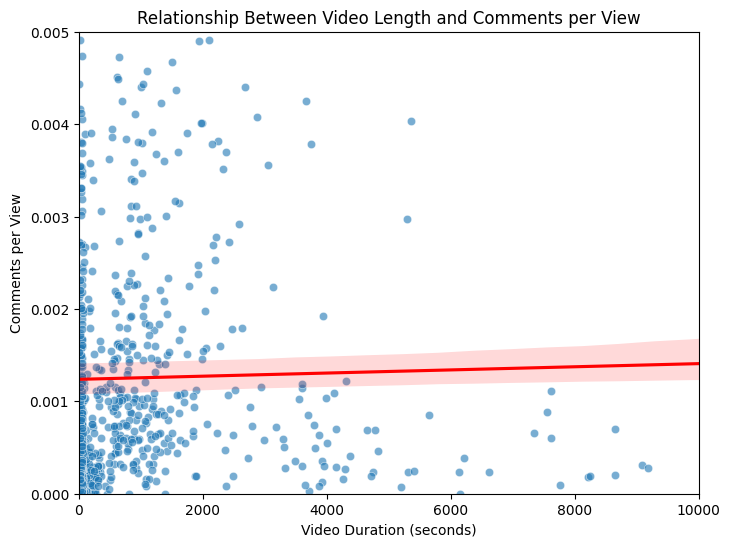

In [24]:
plt.figure(figsize=(8,6))

# Scatter plot
sns.scatterplot(data=df, x='duration_seconds', y='comments_per_view', alpha=0.6)

# Trend line
sns.regplot(data=df, x='duration_seconds', y='comments_per_view', scatter=False, color='red')

# Axis labels and title
plt.xlabel("Video Duration (seconds)")
plt.ylabel("Comments per View")
plt.title("Relationship Between Video Length and Comments per View")
plt.ylim(0, 0.005)
plt.xlim(0, 10000)

plt.show()

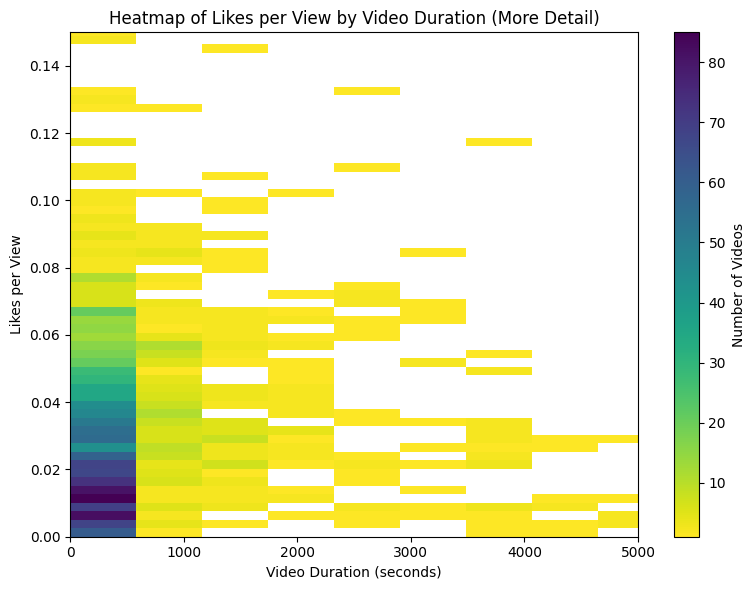

In [10]:
import matplotlib.pyplot as plt
import seaborn as sb
import numpy as np

plt.figure(figsize=[8,6])

# Increase the number of bins for more detail
num_bins_x = 100  # more bins along x-axis (duration)
num_bins_y = 100  # more bins along y-axis (likes_per_view)

# Specify bin edges
bins_x = np.linspace(df['duration_seconds'].min(), df['duration_seconds'].max(), num_bins_x)
bins_y = np.linspace(0, 0.25, num_bins_y)  # limit y-axis to 0.25

plt.hist2d(
    data=df, 
    x='duration_seconds', 
    y='likes_per_view', 
    bins=[bins_x, bins_y], 
    cmap='viridis_r',
    cmin=0.5
)
plt.colorbar(label='Number of Videos')
plt.xlabel('Video Duration (seconds)')
plt.ylabel('Likes per View')
plt.title('Heatmap of Likes per View by Video Duration (More Detail)')
plt.xlim(0, 5000)  # enforce x-axis limit
plt.ylim(0, 0.150)   # enforce y-axis limit

plt.tight_layout()
plt.show()


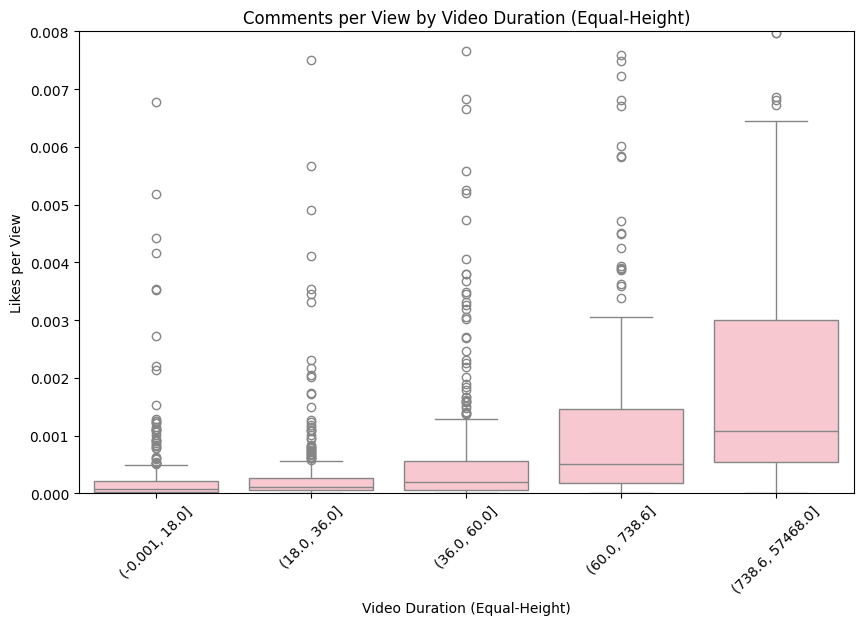

In [11]:

num_quantiles = 5
df['duration_bin_quantile'] = pd.qcut(df['duration_seconds'], q=num_quantiles)

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='duration_bin_quantile', y='comments_per_view', color="pink")
plt.xticks(rotation=45)
plt.xlabel("Video Duration (Equal-Height)")
plt.ylabel("Likes per View")

plt.title("Comments per View by Video Duration (Equal-Height)")
plt.ylim(0, 0.008)
plt.show()

In [27]:
import numpy as np
from scipy import stats

# Define groups (short < 900s, long >= 900s)
short_videos = df[df['duration_seconds'] < 900]
long_videos  = df[df['duration_seconds'] >= 900]

metrics = ['likes_per_view', 'comments_per_view']

for metric in metrics:
    group1 = short_videos[metric].values
    group2 = long_videos[metric].values
    
    mean1 = np.mean(group1)
    mean2 = np.mean(group2)
    diff = mean1 - mean2
    
    t_stat, p_value = stats.ttest_ind(group1, group2, equal_var=False)
    
    print(f"--- {metric} ---")
    print(f"Mean (short videos): {mean1:.4f}")
    print(f"Mean (long videos):  {mean2:.4f}")
    print(f"Difference (short - long): {diff:.4f}")
    print(f"T-test statistic: {t_stat:.4f}")
    print(f"P-value: {p_value:.4f}\n")


--- likes_per_view ---
Mean (short videos): 0.0321
Mean (long videos):  0.0371
Difference (short - long): -0.0050
T-test statistic: -2.3347
P-value: 0.0199

--- comments_per_view ---
Mean (short videos): 0.0010
Mean (long videos):  0.0026
Difference (short - long): -0.0017
T-test statistic: -6.5640
P-value: 0.0000



In [15]:
import pandas as pd
from scipy.stats import chi2_contingency

# Create engagement category (high/low)
df['likes_engagement_cat'] = ['High' if x >= df['likes_per_view'].median() else 'Low' 
                             for x in df['likes_per_view']]

# Crosstab of duration group vs engagement category
contingency_table = pd.crosstab(df['duration_group'], df['likes_engagement_cat'])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Create a table with observed (expected)
combined_table = contingency_table.copy()
for i in contingency_table.index:
    for j in contingency_table.columns:
        combined_table.loc[i, j] = f"{contingency_table.loc[i, j]} ({expected[contingency_table.index.get_loc(i), contingency_table.columns.get_loc(j)]:.2f})"

print("Observed (Expected) Table:\n")
print(combined_table)
print(f"\nChi2 Statistic = {chi2:.3f}, p-value = {p:.4f}")


Observed (Expected) Table:

likes_engagement_cat          High           Low
duration_group                                  
Short                 152 (287.67)  423 (287.33)
Medium                372 (288.67)  205 (288.33)
Long                  339 (286.67)  234 (286.33)

Chi2 Statistic = 195.298, p-value = 0.0000


C:\Users\DELL\AppData\Local\Temp\ipykernel_26504\3355846785.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '152 (287.67)' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  combined_table.loc[i, j] = f"{contingency_table.loc[i, j]} ({expected[contingency_table.index.get_loc(i), contingency_table.columns.get_loc(j)]:.2f})"
C:\Users\DELL\AppData\Local\Temp\ipykernel_26504\3355846785.py:18: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '423 (287.33)' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  combined_table.loc[i, j] = f"{contingency_table.loc[i, j]} ({expected[contingency_table.index.get_loc(i), contingency_table.columns.get_loc(j)]:.2f})"


In [16]:
import pandas as pd
from scipy.stats import chi2_contingency

# Create engagement category (high/low)
df['comments_engagement_cat'] = ['High' if x >= df['comments_per_view'].median() else 'Low' for x in df['comments_per_view']]

# Crosstab of duration group vs engagement category
contingency_table = pd.crosstab(df['duration_group'], df['comments_engagement_cat'])
# Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_table)

# Create a table with observed (expected)
combined_table = contingency_table.copy()
for i in contingency_table.index:
    for j in contingency_table.columns:
        combined_table.loc[i, j] = f"{contingency_table.loc[i, j]} ({expected[contingency_table.index.get_loc(i), contingency_table.columns.get_loc(j)]:.2f})"

print("Observed (Expected) Table:\n")
print(combined_table)
print(f"\nChi2 Statistic = {chi2:.3f}, p-value = {p:.4f}")


Observed (Expected) Table:

comments_engagement_cat          High           Low
duration_group                                     
Short                    135 (287.67)  440 (287.33)
Medium                   253 (288.67)  324 (288.33)
Long                     475 (286.67)   98 (286.33)

Chi2 Statistic = 418.562, p-value = 0.0000


C:\Users\DELL\AppData\Local\Temp\ipykernel_26504\1007293037.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '135 (287.67)' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  combined_table.loc[i, j] = f"{contingency_table.loc[i, j]} ({expected[contingency_table.index.get_loc(i), contingency_table.columns.get_loc(j)]:.2f})"
C:\Users\DELL\AppData\Local\Temp\ipykernel_26504\1007293037.py:16: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '440 (287.33)' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  combined_table.loc[i, j] = f"{contingency_table.loc[i, j]} ({expected[contingency_table.index.get_loc(i), contingency_table.columns.get_loc(j)]:.2f})"


Slope: -2.1928500601568185e-07
Intercept: 0.03316079290332704


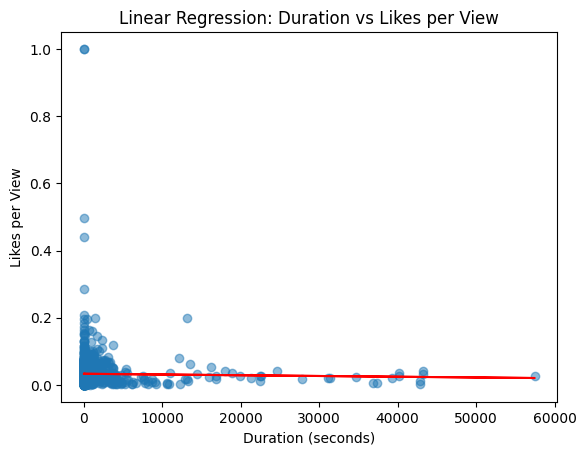

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np

# Example: assuming df is your DataFrame
X = df[['duration_seconds']]  # Independent variable (needs to be 2D)
y = df['likes_per_view']     # Dependent variable

# Create linear regression model
model = LinearRegression()
model.fit(X, y)

# Get slope and intercept
slope = model.coef_[0]
intercept = model.intercept_
print(f"Slope: {slope}")
print(f"Intercept: {intercept}")

# Predict values for plotting
y_pred = model.predict(X)

# Plot
plt.scatter(X, y, alpha=0.5)
plt.plot(X, y_pred, color='red')
plt.xlabel('Duration (seconds)')
plt.ylabel('Likes per View')
plt.title('Linear Regression: Duration vs Likes per View')
plt.show()
# Negative Slope indicates that as duration increases, likes per view tend to decrease